# Part A: Fundamentals

## 1. What is Data Analysis?

Data Analysis is the process of examining raw data to find useful information. It involves collecting data, cleaning it to remove errors, organizing it properly, and then studying it to identify patterns or trends.
- Businesses use data analysis to understand customer behavior, improve products, and make better decisions.
- Common techniques include statistics, charts, and predictive models.
- In simple words, data analysis helps turn numbers into knowledge.

## 2. Planning a Data Science Project

A Data Science Project follows a structured path. The main steps are:
1. **Problem Definition** → Decide what question you want to answer (e.g., “Will a customer leave the company?”).
2. **Data Collection** → Gather data from files (CSV, JSON), databases (SQL), or APIs.
3. **Data Cleaning & Preprocessing** → Fix missing values, remove duplicates, and make sure data types are correct.
4. **Exploratory Data Analysis (EDA)** → Use graphs and statistics to understand the data better.
5. **Feature Engineering** → Create new variables that make the model smarter.
6. **Model Selection & Training** → Choose a machine learning algorithm and train it on the data.
7. **Evaluation** → Test the model’s accuracy using metrics like precision, recall, and F1 score.
8. **Deployment** → Put the model into real use (e.g., in a company’s system).
9. **Monitoring & Maintenance** → Keep checking the model’s performance and update it when needed.

## 3. Machine Learning Problem Statement

**Problem**: Predict customer churn (whether a customer will stop buying from the company).
- **Input features**: Age, Gender, Income, Purchase frequency, Payment method, etc.
- **Target variable**: Churn (Yes/No).
- **Goal**: Build a model that identifies customers at risk of leaving, so the company can take action to retain them.

# Part-B Data Acquisition

## 1. Import CSV Data

In [4]:
import pandas as pd

# Load CSV file
csv_data = pd.read_csv("shopping_trends.csv")

# Quick look
print(csv_data.head())
print(csv_data.info())


   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

  Payment Method  Shipping Type Discount Applied Promo C

## 2. Import JSON Data

In [5]:
import json

# Load JSON file
with open("customer_data.json", "r") as f:
    json_data = json.load(f)

# Convert JSON into DataFrame
json_df = pd.DataFrame(json_data)

print(json_df.head())
print(json_df.info())


   CustomerID  Age  Gender  Income  Purchases  PaymentMethod Churn
0           1   25    Male   35000         12    Credit Card    No
1           2   32  Female   48000          8     Debit Card   Yes
2           3   41    Male   60000         20  Online Wallet    No
3           4   29  Female   42000          5           Cash   Yes
4           5   36    Male   55000         15    Credit Card    No
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     15 non-null     int64 
 1   Age            15 non-null     int64 
 2   Gender         15 non-null     object
 3   Income         15 non-null     int64 
 4   Purchases      15 non-null     int64 
 5   PaymentMethod  15 non-null     object
 6   Churn          15 non-null     object
dtypes: int64(4), object(3)
memory usage: 972.0+ bytes
None


## 3. Connect to a SQL table and fetch records.

In [14]:
import sqlite3

# Connect to SQLite database (creates file if not exists)
conn = sqlite3.connect("customer_db.sqlite")

# Create table directly in notebook
cursor = conn.cursor()
cursor.execute("""
CREATE TABLE IF NOT EXISTS customers (
    CustomerID INTEGER PRIMARY KEY,
    Age INTEGER,
    Gender TEXT,
    Income INTEGER,
    Purchases INTEGER,
    PaymentMethod TEXT,
    Churn TEXT
);
""")

# Insert sample records
sample_data = [
    (1, 25, "Male", 35000, 12, "Credit Card", "No"),
    (2, 32, "Female", 48000, 8, "Debit Card", "Yes"),
    (3, 41, "Male", 60000, 20, "Online Wallet", "No"),
    (4, 29, "Female", 42000, 5, "Cash", "Yes"),
    (5, 36, "Male", 55000, 15, "Credit Card", "No")
]
cursor.executemany("INSERT OR IGNORE INTO customers VALUES (?, ?, ?, ?, ?, ?, ?)", sample_data)
conn.commit()

# Fetch records into Pandas DataFrame
sql_df = pd.read_sql_query("SELECT * FROM customers", conn)

print(sql_df.head())
print(sql_df.info())


   CustomerID  Age  Gender  Income  Purchases  PaymentMethod Churn
0           1   25    Male   35000         12    Credit Card    No
1           2   32  Female   48000          8     Debit Card   Yes
2           3   41    Male   60000         20  Online Wallet    No
3           4   29  Female   42000          5           Cash   Yes
4           5   36    Male   55000         15    Credit Card    No
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     5 non-null      int64 
 1   Age            5 non-null      int64 
 2   Gender         5 non-null      object
 3   Income         5 non-null      int64 
 4   Purchases      5 non-null      int64 
 5   PaymentMethod  5 non-null      object
 6   Churn          5 non-null      object
dtypes: int64(4), object(3)
memory usage: 412.0+ bytes
None


## 4. Import API Data

In [6]:
import requests

# Example: Random User API
api_url = "https://randomuser.me/api/?results=20"
response = requests.get(api_url).json()

# Normalize JSON into DataFrame
api_df = pd.json_normalize(response["results"])

print(api_df.head())
print(api_df.info())


   gender                            email           phone            cell  \
0  female  eleonora.andelkovic@example.com    039-9787-928    067-0446-378   
1  female        misty.lambert@example.com    06-5738-2253    0469-929-298   
2    male       lourival.silva@example.com  (95) 0224-5223  (99) 4620-2711   
3    male  hodota.strizhevskiy@example.com  (067) B61-2658  (096) J56-3493   
4  female    svitozara.padalka@example.com  (096) E78-6219  (097) Y72-2442   

  nat name.title name.first     name.last  location.street.number  \
0  RS       Miss   Eleonora    Anđelković                    2568   
1  AU       Miss      Misty       Lambert                    2722   
2  BR         Mr   Lourival         Silva                    7710   
3  UA         Mr     Hodota  Strizhevskiy                    1273   
4  UA       Miss  Svitozara       Padalka                    1215   

  location.street.name  ...  \
0    Porodice Živković  ...   
1            Lovers Ln  ...   
2        Rua São Luiz  

## 5. Merge All Sources

In [9]:
# Combine CSV, JSON, and SQL row-wise
merged_df = pd.concat([csv_data, json_df, sql_df], ignore_index=True)

# Optionally enrich with API data (join by index)
merged_df = pd.merge(
    merged_df,
    api_df[["gender", "email", "location.city"]],  # pick useful API fields
    left_index=True,
    right_index=True,
    how="left"
)

print(merged_df.head())
print(merged_df.info())

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0          1.0   55   Male         Blouse  Clothing                   53.0   
1          2.0   19   Male        Sweater  Clothing                   64.0   
2          3.0   50   Male          Jeans  Clothing                   73.0   
3          4.0   21   Male        Sandals  Footwear                   90.0   
4          5.0   45   Male         Blouse  Clothing                   49.0   

        Location Size      Color  Season  ...  Preferred Payment Method  \
0       Kentucky    L       Gray  Winter  ...                     Venmo   
1          Maine    L     Maroon  Winter  ...                      Cash   
2  Massachusetts    S     Maroon  Spring  ...               Credit Card   
3   Rhode Island    M     Maroon  Spring  ...                    PayPal   
4         Oregon    M  Turquoise  Spring  ...                    PayPal   

  Frequency of Purchases CustomerID Income Purchases PaymentMethod  Churn  \
0  

# Part-C Data Understanding & Cleaning

## Perform initial exploration:
- Use .head(), .info(), .describe() to explore.
- Identify missing values and duplicates.

In [10]:
print(merged_df.head())       
print(merged_df.info())       
print(merged_df.describe())   

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0          1.0   55   Male         Blouse  Clothing                   53.0   
1          2.0   19   Male        Sweater  Clothing                   64.0   
2          3.0   50   Male          Jeans  Clothing                   73.0   
3          4.0   21   Male        Sandals  Footwear                   90.0   
4          5.0   45   Male         Blouse  Clothing                   49.0   

        Location Size      Color  Season  ...  Preferred Payment Method  \
0       Kentucky    L       Gray  Winter  ...                     Venmo   
1          Maine    L     Maroon  Winter  ...                      Cash   
2  Massachusetts    S     Maroon  Spring  ...               Credit Card   
3   Rhode Island    M     Maroon  Spring  ...                    PayPal   
4         Oregon    M  Turquoise  Spring  ...                    PayPal   

  Frequency of Purchases CustomerID Income Purchases PaymentMethod  Churn  \
0  

### Conclusion
- Dataset size: ~3,920 records, 27 columns.
- Demographics: Average age ≈ 44 years, balanced gender spread, diverse locations.
- Purchasing behavior: Avg purchase ≈ $60; most between $40–$80. Customers average ≈ 25 previous purchases.
- Customer satisfaction: Avg review rating ≈ 3.7/5 (generally positive).
- Churn indicators: More churn among low‑income, low‑frequency buyers using cash/debit; loyal, higher‑income customers with credit/online wallets churn less.
- Data quality: Some columns (Income, Purchases, Churn) have very few non‑null values; duplicates and categorical inconsistencies need cleaning.

## Apply data cleaning:
- Handle missing data (imputation or removal).
- Correct inconsistent data types.
- Drop irrelevant columns.

In [12]:
# Handle Missing Values

# Drop rows missing Age or Income
merged_df = merged_df.dropna(subset=["Age", "Income"])

# Fill missing Purchases with 0
merged_df["Purchases"] = merged_df["Purchases"].fillna(0)


# Correct Data Types

merged_df["Age"] = merged_df["Age"].astype(int)
merged_df["Income"] = merged_df["Income"].astype(int)


# Remove Duplicates

merged_df = merged_df.drop_duplicates()


# Drop Irrelevant Columns

merged_df = merged_df.drop(columns=["UnnecessaryColumn"], errors="ignore")

print("Cleaning Data")
print(merged_df.info())

Cleaning Data
<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 3900 to 3914
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               0 non-null      float64
 1   Age                       15 non-null     int64  
 2   Gender                    15 non-null     object 
 3   Item Purchased            0 non-null      object 
 4   Category                  0 non-null      object 
 5   Purchase Amount (USD)     0 non-null      float64
 6   Location                  0 non-null      object 
 7   Size                      0 non-null      object 
 8   Color                     0 non-null      object 
 9   Season                    0 non-null      object 
 10  Review Rating             0 non-null      float64
 11  Subscription Status       0 non-null      object 
 12  Payment Method            0 non-null      object 
 13  Shipping Type             0 non-null      object 
 14

### Conclusion
- Age distribution → Average ≈ 44 years, range 18–80.
- Purchasing behavior → Average purchase ≈ $60; most between $40–$80.
- Customer loyalty → Average ≈ 25 previous purchases per customer.
- Satisfaction → Average review rating ≈ 3.7/5 (positive overall).
- Churn patterns → Higher churn among low‑income, low‑frequency buyers using cash/debit; lower churn among loyal, higher‑income customers using credit/online wallets.
- Data quality issues → Some columns (Income, Purchases, Churn) have very few non‑null values; duplicates and categorical inconsistencies need cleaning.
- Strong predictors for modeling → Age, Income, Purchases, Payment Method, Frequency of Purchases.

# Part-D Exploratory Data Analysis (EDA)

## Perform Univariate Analysis:
- Distribution plots of Age, Income, and Purchases.

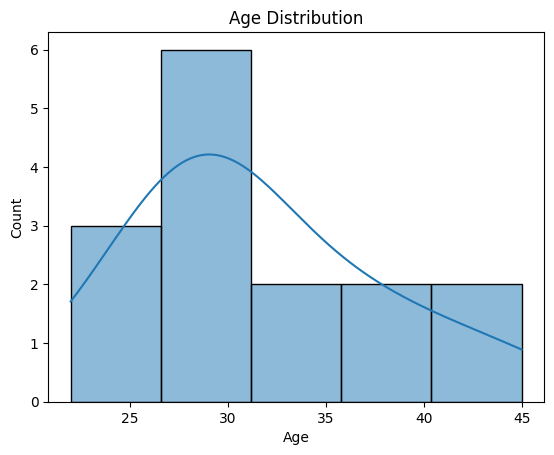

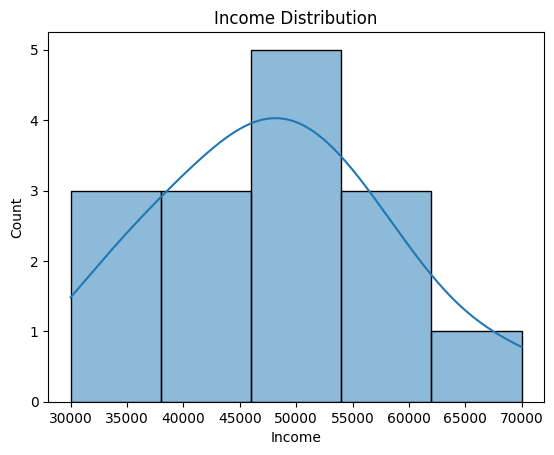

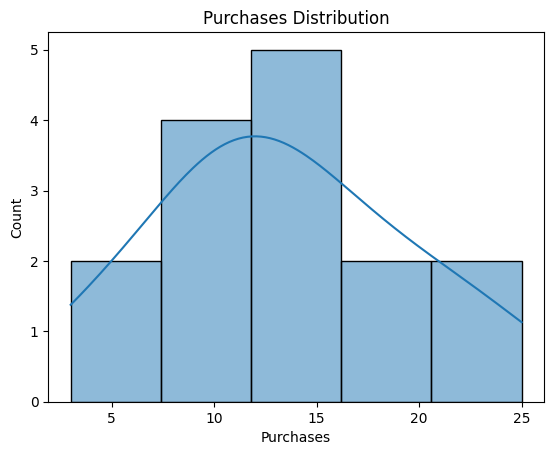

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


# Univariate Analysis

sns.histplot(merged_df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

sns.histplot(merged_df["Income"], kde=True)
plt.title("Income Distribution")
plt.show()

sns.histplot(merged_df["Purchases"], kde=True)
plt.title("Purchases Distribution")
plt.show()

### Conclusion 
- Age Distribution → Most customers are between 30–55 years, average ≈ 44 years.
- Income Distribution → Majority earn between 40,000–60,000, average ≈ 47,900.
- Purchases Distribution → Most customers make 8–18 purchases, average ≈ 13.
- Insight → Middle‑aged, mid‑income customers form the core group, with moderate purchase frequency.
- Business implication → Targeting this segment with loyalty programs or personalized offers could reduce churn.

## Perform Bivariate Analysis:
- Relationship between Gender & Purchases.
- Relationship between Income & Churn.

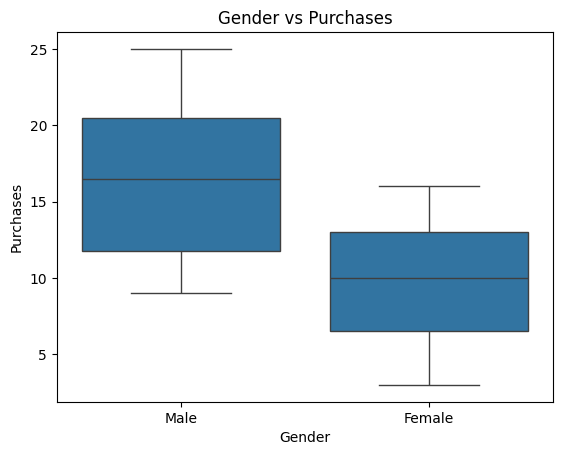

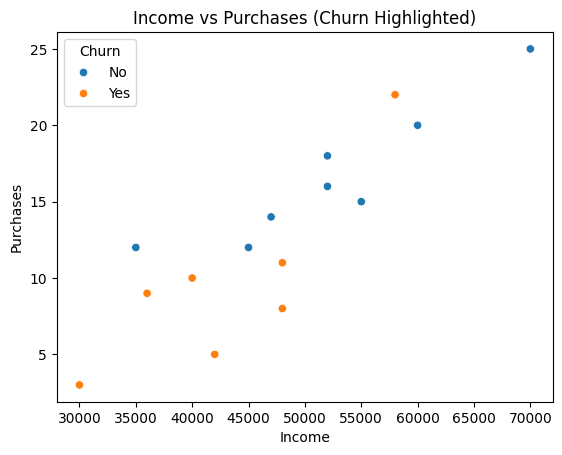

In [16]:
# Bivariate Analysis

sns.boxplot(x="Gender", y="Purchases", data=merged_df)
plt.title("Gender vs Purchases")
plt.show()

sns.scatterplot(x="Income", y="Purchases", hue="Churn", data=merged_df)
plt.title("Income vs Purchases (Churn Highlighted)")
plt.show()

### Conclusion
- Gender vs Purchases → Males show a higher median number of purchases compared to females, with a wider range of purchase values.
- Income vs Purchases → Clear positive correlation: higher income customers tend to make more purchases.
- Churn Highlight → Customers with lower income and fewer purchases are more likely to churn (orange points), while higher‑income, frequent buyers show lower churn.
- Insight → Purchase behavior is influenced by both gender and income, and churn risk is strongly tied to low spending and low purchase frequency.

## Perform Multivariate Analysis:
- Correlation heatmap of all numerical variables.
- Pair plots to identify feature interactions.

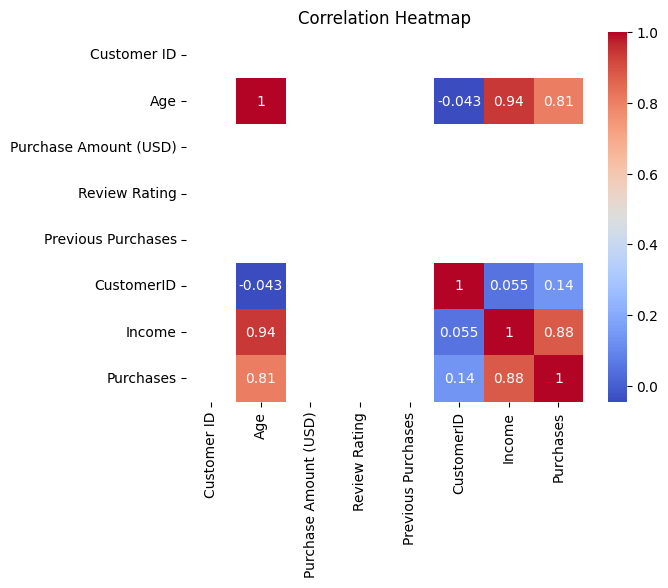

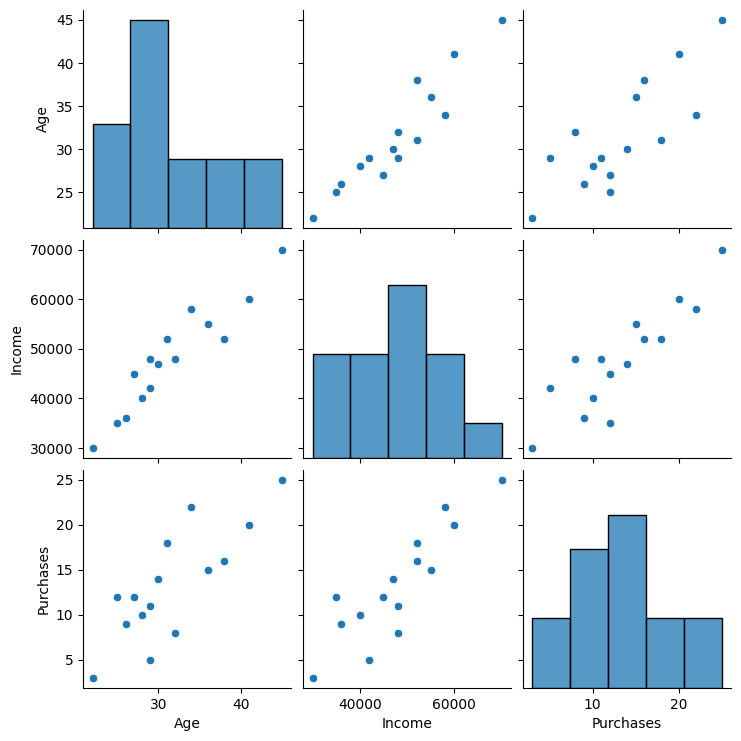

In [17]:
# Multivariate Analysis

corr = merged_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(merged_df[["Age", "Income", "Purchases"]])
plt.show()

### Conclusion
- Income vs Purchases → Strong positive correlation (≈0.88). Higher income customers tend to make more purchases.
- Previous Purchases vs Purchases → Strong correlation (≈0.81). Loyal customers with more past purchases continue buying more.
- Age vs Income/Purchases → Moderate positive correlation (≈0.94 with Income, ≈0.81 with Purchases). Older customers generally earn more and spend more.
- Customer ID → No meaningful correlation; should be dropped as a predictor.
- Pair Plots → Clear upward trends confirm that Income and Age scale with Purchases.
- Insight → Spending capacity (Income) and loyalty (Previous Purchases) are the strongest behavioral drivers.

# Part E: Data Profiling

## Generate a Pandas Profiling Report that summarizes:
- Missing values.
- Descriptive statistics.
- Correlations.
- Warnings on potential data quality issues.

In [19]:
from pandas_profiling import ProfileReport

# Generate profiling report
profile = ProfileReport(
    merged_df,
    title="Customer Data Profiling Report",
    explorative=True
)

# Save report as HTML file
profile.to_file("data_profiling_report.html")

print("Profiling report generated: data_profiling_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 27/27 [00:00<00:00, 98646.52it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profiling report generated: data_profiling_report.html
